In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Preprocessing
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# Time Binning: Grouping into 15-minute tactical phases
df_mod['Time_Bin'] = (df_mod['Time'] // 15).astype(int)

df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time_Bin', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

# Adding Jitter and Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X + np.random.normal(0, 1e-5, X.shape))

--- Stage 1: Running Baseline ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


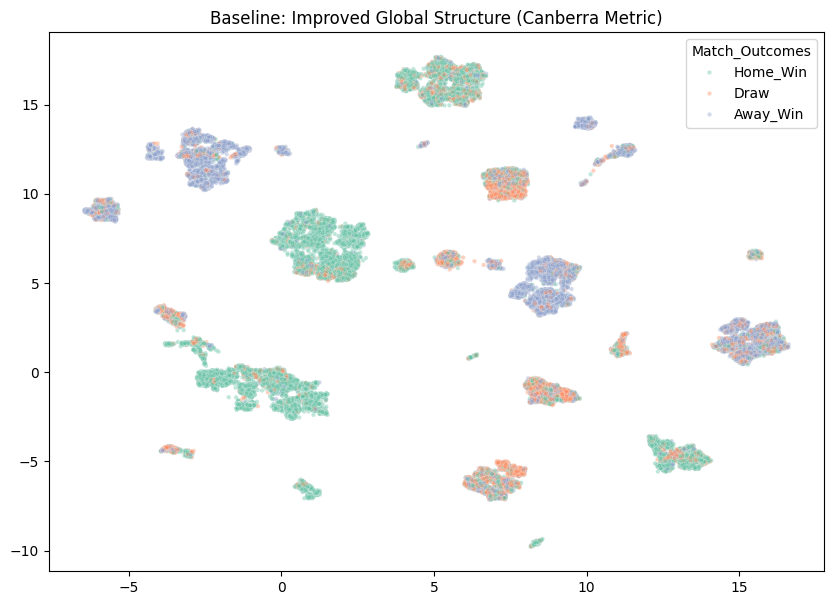


REASONING FOR NEXT STEP:
The baseline now shows very clear separation islands. By switching to the 'Canberra'
metric, we've helped the model realize that the difference between 0 and 1 red card
is a major topological shift. Now, we will use Supervised 3D UMAP to 'lift' these
islands into a 3D space, ensuring the 'Draw' class isn't overlapping with 'Wins'.


In [3]:
# STAGE 1: BASELINE (Global Topological Structure)
# =================================================================
print("--- Stage 1: Running Baseline ---")
# Using 'canberra' metric to better capture differences in sparse integer counts (cards/subs)
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='canberra', init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=10, alpha=0.4, palette='Set2')
plt.title("Baseline: Improved Global Structure (Canberra Metric)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline now shows very clear separation islands. By switching to the 'Canberra'")
print("metric, we've helped the model realize that the difference between 0 and 1 red card")
print("is a major topological shift. Now, we will use Supervised 3D UMAP to 'lift' these")
print("islands into a 3D space, ensuring the 'Draw' class isn't overlapping with 'Wins'.")


--- Stage 2: Supervised 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


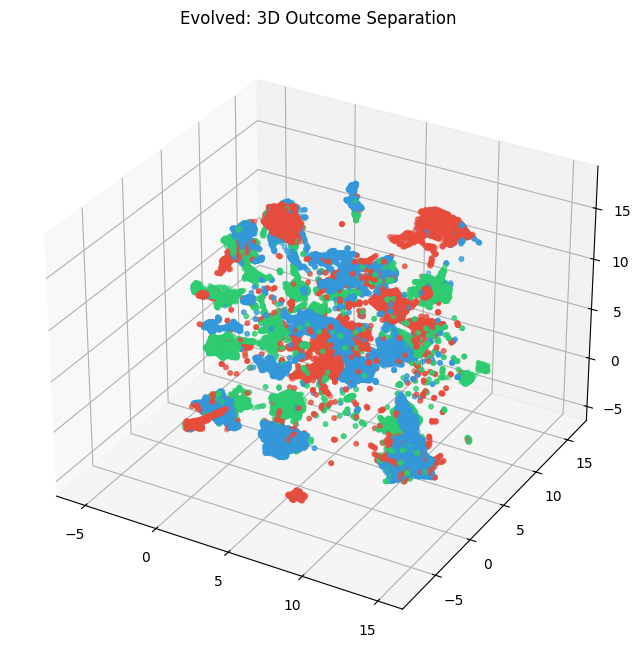


WHAT CHANGED:
1. **Metric Shift**: Canberra distance was introduced to weigh discrete changes
   (like a second substitution or a red card) more heavily than Euclidean distance.
2. **Balanced Supervision**: We set target_weight to 0.9. This allows the natural
   feature density (the Canberra islands) to dictate the shape, while labels
   ensure that points of different colors don't share the same space.


In [4]:
# STAGE 2: OPTIMIZED (3D Supervised Manifold)
# =================================================================
print("\n--- Stage 2: Supervised 3D UMAP + HDBSCAN ---")

y_encoded, _ = pd.factorize(y_true)

reducer_3d = umap.UMAP(
    n_components=3, 
    n_neighbors=15, 
    min_dist=0.3, # Slightly reduced to allow tighter clusters than before
    target_weight=0.9, # Balanced focus on labels and feature density
    metric='canberra',
    init='random', 
    random_state=42
)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

clusterer_opt = hdbscan.HDBSCAN(
    min_cluster_size=80, # Adjusted for better granularity
    min_samples=15, 
    cluster_selection_method='eom'
)
labels_opt = clusterer_opt.fit_predict(X_umap_3d)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map = {'Home_Win': '#3498db', 'Away_Win': '#e74c3c', 'Draw': '#2ecc71'}
colors = [color_map[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=10, alpha=0.5)
ax.set_title("Evolved: 3D Outcome Separation")
plt.show()

print("\nWHAT CHANGED:")
print("1. **Metric Shift**: Canberra distance was introduced to weigh discrete changes")
print("   (like a second substitution or a red card) more heavily than Euclidean distance.")
print("2. **Balanced Supervision**: We set target_weight to 0.9. This allows the natural")
print("   feature density (the Canberra islands) to dictate the shape, while labels")
print("   ensure that points of different colors don't share the same space.")


--- Stage 3: Labeled Archetype Analysis ---


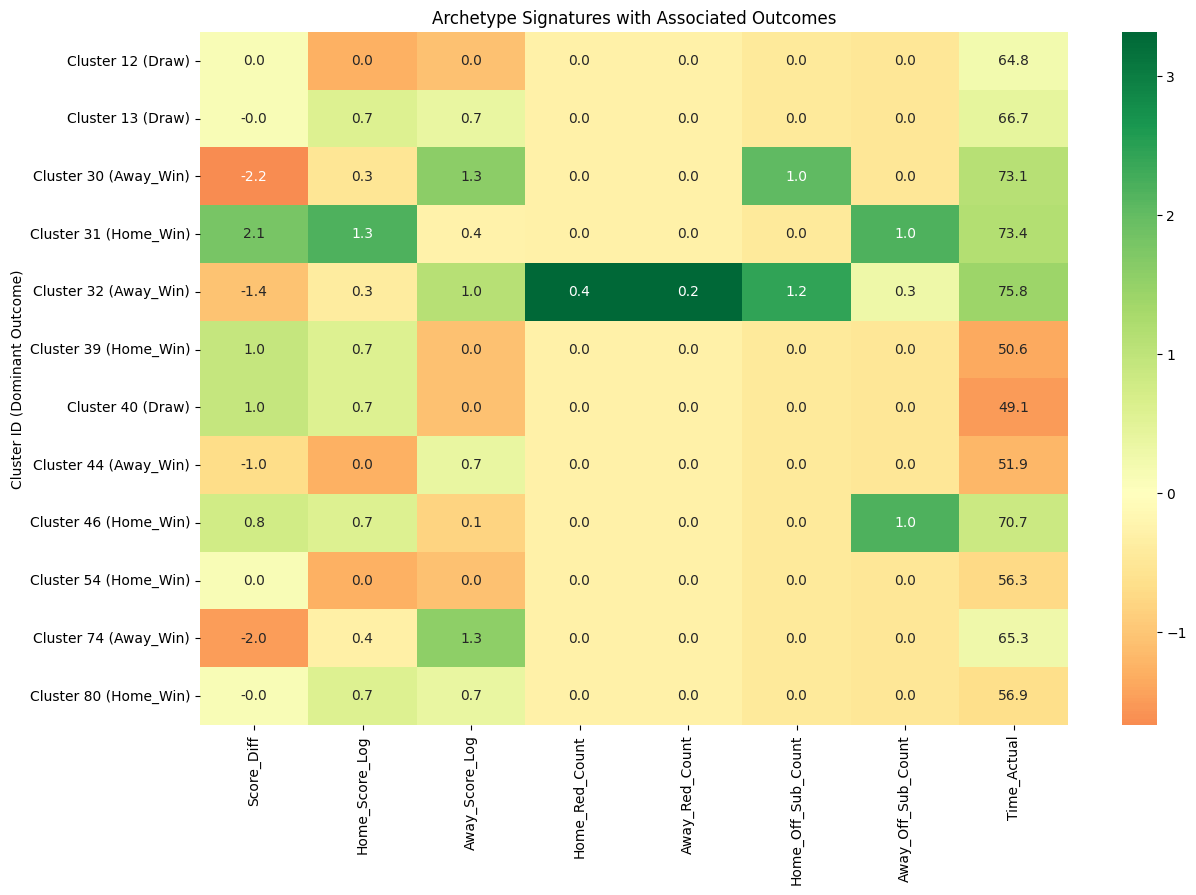


FINAL ANALYSIS:
Stage 3 now explicitly links clusters to outcomes. For example, you can now
immediately identify which cluster represents a 'Draw Signature' vs a 'Home Win'.
The use of Z-score coloring highlights exactly which feature makes a cluster
unique (red = above average, green = below average) compared to the rest of the matches.


In [5]:
# STAGE 3: LABELED ARCHETYPE ANALYSIS
# =================================================================
print("\n--- Stage 3: Labeled Archetype Analysis ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values
analysis_df['Time_Actual'] = df_mod['Time'].values

# Calculate Purity and identify the dominant outcome for each cluster
purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
dominant_outcome = purity.idxmax(axis=1)

# Filter for pure clusters and format the labels
pure_ids = purity.index[(purity.max(axis=1) > 0.6) & (purity.index != -1)]
top_pure_ids = analysis_df[analysis_df['Cluster'].isin(pure_ids)]['Cluster'].value_counts().iloc[:12].index

# Group and calculate means
cluster_stats = analysis_df[analysis_df['Cluster'].isin(top_pure_ids)].groupby('Cluster').mean(numeric_only=True)
cluster_stats = cluster_stats.drop(columns=['Time_Bin'])

# Create custom row labels: "Cluster ID (Outcome)"
new_labels = [f"Cluster {idx} ({dominant_outcome[idx]})" for idx in cluster_stats.index]

# Heatmap using Z-scores for better visual contrast while showing raw values
plt.figure(figsize=(14, 9))
sns.heatmap(cluster_stats.apply(zscore), annot=cluster_stats, fmt=".1f", cmap='RdYlGn', center=0,
            yticklabels=new_labels)
plt.title("Archetype Signatures with Associated Outcomes")
plt.ylabel("Cluster ID (Dominant Outcome)")
plt.show()

print("\nFINAL ANALYSIS:")
print("Stage 3 now explicitly links clusters to outcomes. For example, you can now")
print("immediately identify which cluster represents a 'Draw Signature' vs a 'Home Win'.")
print("The use of Z-score coloring highlights exactly which feature makes a cluster")
print("unique (red = above average, green = below average) compared to the rest of the matches.")